In [3]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import pickle
import matplotlib.pyplot as plt
from src.indices_and_metrics import build_metric_dataframe, shannon_index, mean_feature
from src.validation_summary import run_validation

In [4]:
from pathlib import Path
import pickle

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_PKL_PATH = REPO_ROOT / 'scripts' / 'data.pkl'

with open(DATA_PKL_PATH, 'rb') as f:
    data = pickle.load(f)

print(f'Loaded from: {DATA_PKL_PATH}')

Loaded from: D:\Drive F 5-11-2024\A_BiosCape_Project3\AVIRIS-NG simulated Images\Scene_Validation\Simulated VS Real Drone Validation Repos\scripts\data.pkl


In [5]:
years = [2006, 2016, 2019]
df_real = []
df_sim = []
for year in years:
    df_real.append(build_metric_dataframe(data[f'real_Red_{year}'], data[f'real_Green_{year}'], data[f'real_NIR_{year}'], data[f'real_Rededge_{year}'], year))
    df_sim.append(build_metric_dataframe(data[f'sim_Red_{year}'], data[f'sim_Green_{year}'], data[f'sim_NIR_{year}'], data[f'sim_Rededge_{year}'], year))
df_real[0].head()


d:\Drive F 5-11-2024\A_BiosCape_Project3\AVIRIS-NG simulated Images\Scene_Validation\Simulated VS Real Drone Validation Repos\src\indices_and_metrics.py:72: RuntimeWarning: invalid value encountered in sqrt
  indices["RDVI"]   = np.sqrt((NIR - R) / (NIR + R + eps))
d:\Drive F 5-11-2024\A_BiosCape_Project3\AVIRIS-NG simulated Images\Scene_Validation\Simulated VS Real Drone Validation Repos\src\indices_and_metrics.py:91: RuntimeWarning: invalid value encountered in power
  indices["AVI"]    = (NIR * (1 - R) * (NIR - R))**(1/3)
d:\Drive F 5-11-2024\A_BiosCape_Project3\AVIRIS-NG simulated Images\Scene_Validation\Simulated VS Real Drone Validation Repos\src\indices_and_metrics.py:72: RuntimeWarning: invalid value encountered in sqrt
  indices["RDVI"]   = np.sqrt((NIR - R) / (NIR + R + eps))
d:\Drive F 5-11-2024\A_BiosCape_Project3\AVIRIS-NG simulated Images\Scene_Validation\Simulated VS Real Drone Validation Repos\src\indices_and_metrics.py:91: RuntimeWarning: invalid value encountered in p

,Red,Green,NIR,RE,Year,NDVI,ReCI,NDRE,GNDVI,OSAVI,...,LCI,EVI,MEVI,SARE,RTVI,REGNDVI,ARI2,ratio1,ratio2,GDVI_sq
0,0.016392,0.022902,0.246497,0.076858,2006,0.875291,2.207184,0.524623,0.829976,0.544125,...,0.645288,0.490383,0.276127,0.654250,14.727961,0.540856,7.555891,0.428036,0.054416,0.991194
1,0.015994,0.024097,0.242023,0.073946,2006,0.876022,2.272954,0.531940,0.818904,0.540716,...,0.651416,0.488282,0.279201,0.652023,14.628386,0.508448,6.770895,0.410263,0.065790,0.991303
2,0.014898,0.021806,0.240198,0.073140,2006,0.883194,2.284078,0.533155,0.833544,0.542765,...,0.654881,0.483043,0.275583,0.650563,14.521880,0.540664,7.731093,0.433928,0.043331,0.992335
3,0.014167,0.021571,0.220533,0.074323,2006,0.879276,1.967213,0.495868,0.821806,0.522843,...,0.622964,0.451072,0.242923,0.619021,12.631367,0.550114,7.256539,0.497747,0.027575,0.991780
4,0.014041,0.020624,0.202166,0.064353,2006,0.870112,2.141523,0.517086,0.814859,0.500056,...,0.637412,0.415567,0.240326,0.605360,11.965898,0.514602,6.661063,0.380957,0.061364,0.990398


In [6]:
metrics = ['NDVI', 'CVI', 'GNDVI', 'NIRv', 'NormNIR', 'LCI', 'Red', 'Green', 'NIR', 'RE']
validation_df = run_validation(df_real, df_sim, metrics, years)
validation_df.round(4)


,Year,Metric,RMSE,MAE,MBE,Pearson,Spearman,CCC,KS_stat,KS_pvalue
0,2006,NDVI,0.1828,0.1111,-0.0313,-0.0074,-0.0076,-0.0051,0.0755,0.0
1,2006,CVI,4.8978,2.7440,-1.1319,0.0018,0.0073,0.0011,0.4130,0.0
2,2006,GNDVI,0.1804,0.1090,-0.0613,-0.0013,-0.0020,-0.0006,0.2763,0.0
3,2006,NIRv,0.1242,0.1010,-0.0397,0.0010,0.0006,0.0009,0.3408,0.0
4,2006,NormNIR,0.1168,0.0784,-0.0298,-0.0057,-0.0053,-0.0039,0.1711,0.0
5,2006,LCI,0.2592,0.2393,-0.2391,-0.0082,-0.0080,-0.0011,0.9609,0.0
6,2006,Red,0.0237,0.0196,-0.0064,-0.0050,-0.0037,-0.0040,0.3432,0.0
7,2006,Green,0.0267,0.0218,-0.0033,-0.0010,0.0004,-0.0008,0.3014,0.0
8,2006,NIR,0.1553,0.1280,-0.0512,0.0007,0.0012,0.0005,0.3558,0.0
9,2006,RE,0.0907,0.0722,0.0270,0.0010,0.0016,0.0007,0.2880,0.0


In [7]:
percent_cover_2006 = [12, 15, 25, 0.5, 13, 5, 4, 3, 0.5, 5, 1, 1]
percent_cover_2016 = [15, 23, 1, 6, 5, 10, 8, 1, 5, 2, 1, 2, 1]
percent_cover_2019 = [5, 5, 2, 25, 22, 5, 5, 5, 5, 3, 5, 3]
shannon_indices = [shannon_index(percent_cover_2006), shannon_index(percent_cover_2016), shannon_index(percent_cover_2019)]
shannon_indices


Shannon Diversity Index: 1.9897322407613862
Shannon Diversity Index: 2.1068262858209836
Shannon Diversity Index: 2.135552730064598


[1.9897322407613862, 2.1068262858209836, 2.135552730064598]

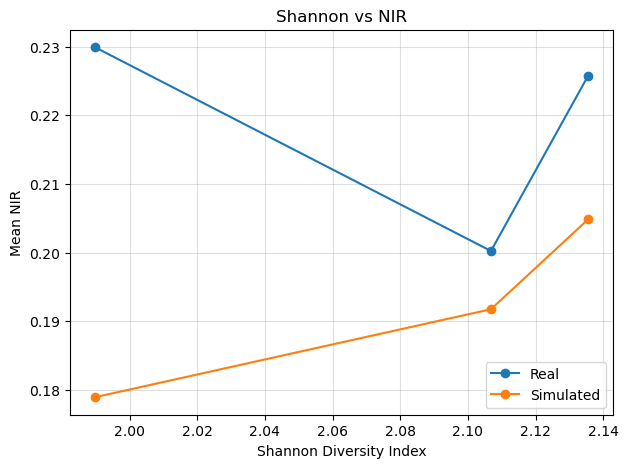

In [ ]:
metric = 'NIR'
real_mean = mean_feature(df_real, metric)
sim_mean = mean_feature(df_sim, metric)
plt.figure(figsize=(7,5))
plt.plot(shannon_indices, real_mean, marker='o', label='Real')
plt.plot(shannon_indices, sim_mean, marker='o', label='Simulated')
plt.xlabel('Shannon Diversity Index')
plt.ylabel(f'Mean {metric}')
plt.title(f'Shannon vs {metric}')
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()
